# E-commerce Sales Analysis

Exploratory data analysis of e-commerce order data, focused on sales performance. This notebook reproduces the original analysis with a documented, configurable structure: change the period in the Configuration section and re-run all cells to analyze any year or month.

The data and metric logic live in two reusable modules:

- `data_loader.py` - loads the raw CSVs, builds a single analysis-ready sales table, and filters it by period.
- `business_metrics.py` - pure metric calculations (no I/O, no plotting).

## Table of Contents

1. [Introduction and Business Objectives](#1.-Introduction-and-Business-Objectives)
2. [Data Dictionary](#2.-Data-Dictionary)
3. [Configuration](#3.-Configuration)
4. [Data Loading](#4.-Data-Loading)
5. [Data Preparation and Transformation](#5.-Data-Preparation-and-Transformation)
6. [Business Metrics](#6.-Business-Metrics)
    - [6.1 Revenue Analysis](#6.1-Revenue-Analysis)
    - [6.2 Product Analysis](#6.2-Product-Analysis)
    - [6.3 Geographic Analysis](#6.3-Geographic-Analysis)
    - [6.4 Customer Experience Analysis](#6.4-Customer-Experience-Analysis)
7. [Summary of Observations](#7.-Summary-of-Observations)

## 1. Introduction and Business Objectives

This analysis examines delivered-order sales to answer recurring business questions:

- How much revenue was generated in the analysis period, and how does it compare to the prior year?
- What is the month-over-month revenue trend within the period?
- How are average order value and total order count changing year over year?
- Which product categories generate the most revenue?
- How is revenue distributed geographically across states?
- How do delivery times relate to customer review scores, and what does the overall customer experience look like?

Revenue figures are based on delivered orders only, so cancellations and other non-completed statuses do not inflate sales.

## 2. Data Dictionary

Key columns and business terms used in this analysis.

| Term | Definition |
| --- | --- |
| order_id | Unique identifier of an order. An order can contain multiple line items. |
| order_item_id | Sequence number of a line item within an order. |
| price | Item price. Revenue is the sum of this column over delivered orders. |
| order_status | Order lifecycle status. Sales metrics use only `delivered` orders. |
| order_purchase_timestamp | When the order was placed; source of the `year` and `month` columns. |
| order_delivered_customer_date | When the order reached the customer. |
| delivery_days | Whole days between purchase and delivery to the customer. |
| product_category_name | Category of the purchased product. |
| customer_state | US state of the customer, used for geographic analysis. |
| review_score | Customer review rating from 1 (lowest) to 5 (highest). |

| Metric | Definition |
| --- | --- |
| Total revenue | Sum of item `price` across delivered orders in the period. |
| Average order value (AOV) | Mean of per-order revenue totals. |
| Order count | Number of distinct delivered orders. |
| Month-over-month growth | Period-over-period change in monthly revenue. |
| Year-over-year growth | Fractional change between the analysis and comparison periods. |

## 3. Configuration

Set the analysis period and shared styling here. Change `ANALYSIS_YEAR`, `COMPARISON_YEAR`, or `ANALYSIS_MONTH` and re-run all cells to analyze a different period. Set `ANALYSIS_MONTH` to a number from 1 to 12 to restrict the analysis to a single month, or leave it as `None` for the full year.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

import data_loader
import business_metrics as bm

# Analysis period (edit these and re-run all cells).
DATA_DIR = "ecommerce_data"
ANALYSIS_YEAR = 2023
COMPARISON_YEAR = 2022
ANALYSIS_MONTH = None  # 1-12 for a single month, or None for the full year

# Business color palette, applied consistently across all charts.
PRIMARY_COLOR = "#1f4e79"    # deep corporate blue
SEQUENTIAL_SCALE = "Blues"   # sequential scale for the choropleth map


def period_label(year, month=None):
    """Return a human-readable label for a year and optional month."""
    if month is None:
        return str(year)
    return f"{pd.Timestamp(year=year, month=month, day=1):%B %Y}"


ANALYSIS_LABEL = period_label(ANALYSIS_YEAR, ANALYSIS_MONTH)
COMPARISON_LABEL = period_label(COMPARISON_YEAR, ANALYSIS_MONTH)

print(f"Analysis period: {ANALYSIS_LABEL}")
print(f"Comparison period: {COMPARISON_LABEL}")

Analysis period: 2023
Comparison period: 2022


## 4. Data Loading

Load the raw CSV datasets. Each is returned as a DataFrame keyed by name.

In [2]:
datasets = data_loader.load_raw_datasets(DATA_DIR)

orders = datasets["orders"]
order_items = datasets["order_items"]
products = datasets["products"]
customers = datasets["customers"]
reviews = datasets["reviews"]

for name, frame in datasets.items():
    print(f"{name}: {frame.shape[0]} rows, {frame.shape[1]} columns")

orders: 10000 rows, 8 columns
order_items: 16047 rows, 7 columns
products: 6000 rows, 9 columns
customers: 8000 rows, 5 columns
reviews: 6571 rows, 7 columns
payments: 14091 rows, 5 columns


## 5. Data Preparation and Transformation

Build a single analysis-ready sales table with one row per order line item. The loader merges order items with orders, parses timestamps, derives the `year`, `month`, and `delivery_days` columns, and enriches each row with product category and customer state.

In [3]:
sales = data_loader.build_sales_dataset(orders, order_items, products, customers)
sales.head()

,order_id,order_item_id,product_id,price,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,year,month,delivery_days,product_category_name,customer_state
0,ord_d25ca0e820f231046c70dd33,1,prod_f81e246eb80a8c0d2b147727,552.30,cust_d6ec876eea63d04ced06e168,canceled,2023-04-24 12:18:14.590086,NaT,2023,4,NaN,electronics,IL
1,ord_d25ca0e820f231046c70dd33,2,prod_2a39feb460adb7e5f843aeaf,1155.65,cust_d6ec876eea63d04ced06e168,canceled,2023-04-24 12:18:14.590086,NaT,2023,4,NaN,electronics,IL
2,ord_5fa044951857e02fd1347b47,1,prod_9b6f1793388ae983f852d189,111.91,cust_2d36e4b647be13c15df550af,delivered,2023-04-24 13:05:32.579655,2023-05-01 02:05:32.579655,2023,4,6.0,grocery_gourmet_food,TN
3,ord_5fa044951857e02fd1347b47,2,prod_c7b5997a4d0061a9f50e874c,878.42,cust_2d36e4b647be13c15df550af,delivered,2023-04-24 13:05:32.579655,2023-05-01 02:05:32.579655,2023,4,6.0,electronics,TN
4,ord_0a02a8a1d3d282380ed7d0cc,1,prod_d5f7b6e420ea5cffc504ab21,1030.31,cust_157f0ea0316c546ac08dae30,delivered,2022-05-15 07:51:22.471390,2022-05-23 01:51:22.471390,2022,5,7.0,home_garden,IL


Filter the sales table to the analysis and comparison periods. Both use the same configurable filter, so all downstream metrics work for any year or month.

In [4]:
analysis_sales = data_loader.filter_sales(sales, year=ANALYSIS_YEAR, month=ANALYSIS_MONTH)
comparison_sales = data_loader.filter_sales(sales, year=COMPARISON_YEAR, month=ANALYSIS_MONTH)

print(f"Analysis rows ({ANALYSIS_LABEL}): {len(analysis_sales)}")
print(f"Comparison rows ({COMPARISON_LABEL}): {len(comparison_sales)}")
analysis_sales.head()

Analysis rows (2023): 7448
Comparison rows (2022): 7641


,order_id,order_item_id,product_id,price,customer_id,order_status,order_purchase_timestamp,order_delivered_customer_date,year,month,delivery_days,product_category_name,customer_state
2,ord_5fa044951857e02fd1347b47,1,prod_9b6f1793388ae983f852d189,111.91,cust_2d36e4b647be13c15df550af,delivered,2023-04-24 13:05:32.579655,2023-05-01 02:05:32.579655,2023,4,6.0,grocery_gourmet_food,TN
3,ord_5fa044951857e02fd1347b47,2,prod_c7b5997a4d0061a9f50e874c,878.42,cust_2d36e4b647be13c15df550af,delivered,2023-04-24 13:05:32.579655,2023-05-01 02:05:32.579655,2023,4,6.0,electronics,TN
7,ord_43b53981d951f855231d09ec,1,prod_496e129d773e9587e8ddc065,749.83,cust_e670ce607e4f6aa14935ece0,delivered,2023-12-10 05:13:58.249202,2023-12-19 09:13:58.249202,2023,12,9.0,sports_outdoors,FL
8,ord_e60b1e267fd32d93c4d0745b,1,prod_139fc7c40b163ec81342741e,361.54,cust_deec5ec61bd39869531896b3,delivered,2023-04-11 05:42:57.214593,2023-04-22 20:42:57.214593,2023,4,11.0,home_garden,PA
9,ord_e60b1e267fd32d93c4d0745b,2,prod_8668b3ebccd7183bae97138a,25.59,cust_deec5ec61bd39869531896b3,delivered,2023-04-11 05:42:57.214593,2023-04-22 20:42:57.214593,2023,4,11.0,grocery_gourmet_food,PA


## 6. Business Metrics

### 6.1 Revenue Analysis

Total revenue for the analysis period and its year-over-year change against the comparison period.

In [5]:
analysis_revenue = bm.total_revenue(analysis_sales)
comparison_revenue = bm.total_revenue(comparison_sales)
revenue_growth = bm.growth_rate(analysis_revenue, comparison_revenue)

print(f"Total revenue ({ANALYSIS_LABEL}): {analysis_revenue:,.2f}")
print(f"Total revenue ({COMPARISON_LABEL}): {comparison_revenue:,.2f}")
print(f"Year-over-year revenue growth: {revenue_growth * 100:.2f}%")

Total revenue (2023): 3,360,294.74
Total revenue (2022): 3,445,076.96
Year-over-year revenue growth: -2.46%


Month-over-month revenue growth within the analysis period. The first month is `NaN` because it has no prior month to compare against.

In [6]:
monthly_growth = bm.monthly_growth(analysis_sales)
average_monthly_growth = bm.average_monthly_growth(analysis_sales)

print(f"Month-over-month revenue growth, percent ({ANALYSIS_LABEL}):")
print((monthly_growth * 100).round(2))
print(f"\nAverage month-over-month growth: {average_monthly_growth * 100:.2f}%")

Month-over-month revenue growth, percent (2023):
month
1       NaN
2     -2.84
3      3.20
4    -11.14
5     18.74
6     -4.06
7      2.45
8     -3.23
9      5.98
10   -14.45
11    -0.14
12     1.24
Name: price, dtype: float64

Average month-over-month growth: -0.39%


Average order value and total order count, each compared year over year.

In [7]:
analysis_aov = bm.average_order_value(analysis_sales)
comparison_aov = bm.average_order_value(comparison_sales)
aov_growth = bm.growth_rate(analysis_aov, comparison_aov)

print(f"Average order value ({ANALYSIS_LABEL}): {analysis_aov:,.2f}")
print(f"Average order value ({COMPARISON_LABEL}): {comparison_aov:,.2f}")
print(f"Year-over-year change: {aov_growth * 100:.2f}%")

Average order value (2023): 724.98
Average order value (2022): 725.43
Year-over-year change: -0.06%


In [8]:
analysis_order_count = bm.order_count(analysis_sales)
comparison_order_count = bm.order_count(comparison_sales)
order_count_growth = bm.growth_rate(analysis_order_count, comparison_order_count)

print(f"Total orders ({ANALYSIS_LABEL}): {analysis_order_count}")
print(f"Total orders ({COMPARISON_LABEL}): {comparison_order_count}")
print(f"Year-over-year change: {order_count_growth * 100:.2f}%")

Total orders (2023): 4635
Total orders (2022): 4749
Year-over-year change: -2.40%


Monthly revenue trend across the analysis period.

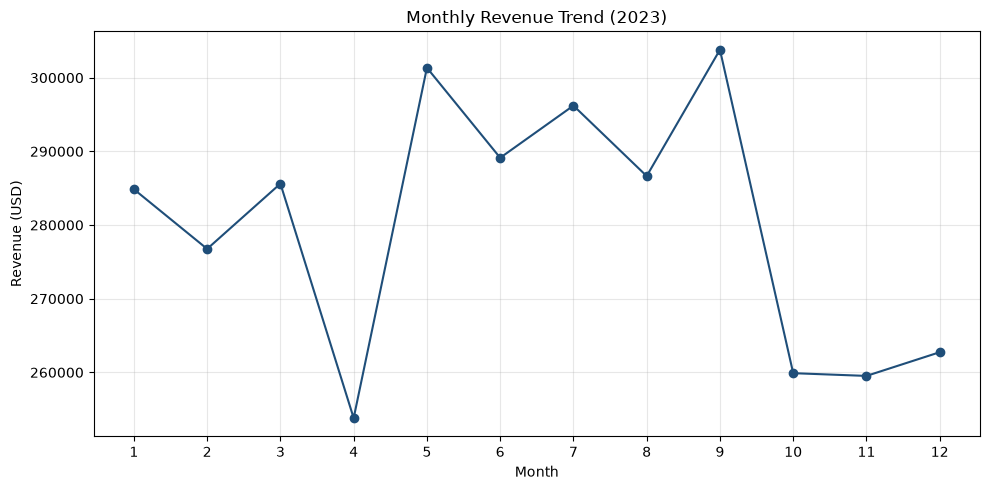

In [9]:
monthly_rev = bm.monthly_revenue(analysis_sales)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(monthly_rev.index, monthly_rev.values, marker="o", color=PRIMARY_COLOR)
ax.set_title(f"Monthly Revenue Trend ({ANALYSIS_LABEL})")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (USD)")
ax.set_xticks(list(monthly_rev.index))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2 Product Analysis

Revenue by product category, ranked from highest to lowest.

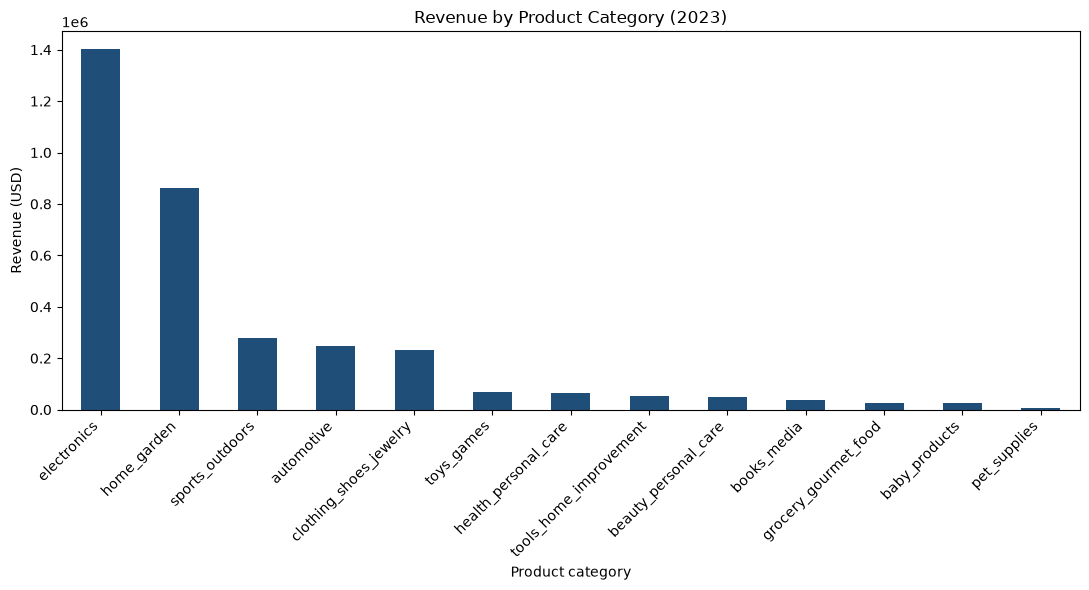

In [10]:
category_revenue = bm.revenue_by_category(analysis_sales)

fig, ax = plt.subplots(figsize=(11, 6))
category_revenue.plot(kind="bar", ax=ax, color=PRIMARY_COLOR)
ax.set_title(f"Revenue by Product Category ({ANALYSIS_LABEL})")
ax.set_xlabel("Product category")
ax.set_ylabel("Revenue (USD)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 6.3 Geographic Analysis

Revenue by US state, shown as a choropleth map.

In [11]:
state_revenue = bm.revenue_by_state(analysis_sales)

fig = px.choropleth(
    state_revenue,
    locations="customer_state",
    color="price",
    locationmode="USA-states",
    scope="usa",
    color_continuous_scale=SEQUENTIAL_SCALE,
    labels={"price": "Revenue (USD)", "customer_state": "State"},
    title=f"Revenue by State ({ANALYSIS_LABEL})",
)
fig.show()

### 6.4 Customer Experience Analysis

Join reviews to delivered orders in the analysis period, deduplicated to one row per order, then examine review scores, delivery times, and order statuses.

In [12]:
review_delivery = data_loader.build_review_delivery_table(analysis_sales, reviews)

average_review = bm.average_review_score(review_delivery)
average_delivery = bm.average_delivery_days(review_delivery)

print(f"Average review score ({ANALYSIS_LABEL}): {average_review:.3f}")
print(f"Average delivery time ({ANALYSIS_LABEL}): {average_delivery:.2f} days")

Average review score (2023): 4.102
Average delivery time (2023): 8.01 days


Distribution of review scores.

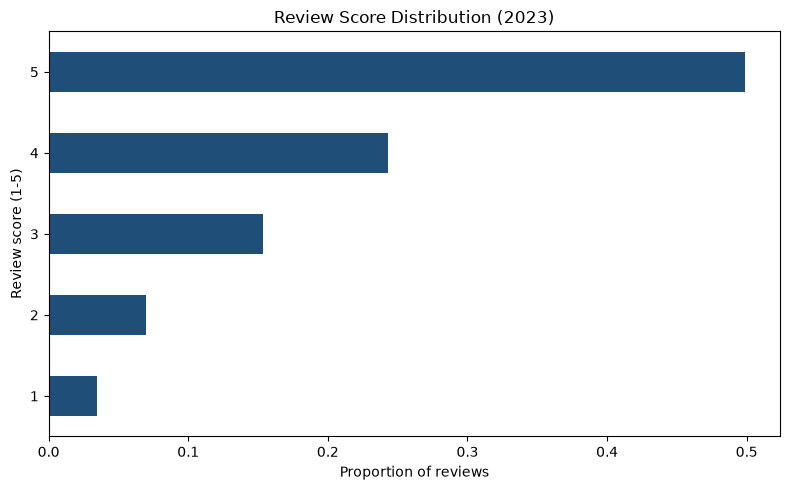

In [13]:
score_distribution = bm.review_score_distribution(review_delivery).sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
score_distribution.plot(kind="barh", ax=ax, color=PRIMARY_COLOR)
ax.set_title(f"Review Score Distribution ({ANALYSIS_LABEL})")
ax.set_xlabel("Proportion of reviews")
ax.set_ylabel("Review score (1-5)")
plt.tight_layout()
plt.show()

Average review score by delivery duration: first per whole day, then grouped into delivery-speed buckets.

In [14]:
bm.review_by_delivery_days(review_delivery)

,delivery_days,review_score
0,2.0,4.033898
1,3.0,4.248555
2,4.0,4.068000
3,5.0,4.054054
4,6.0,4.073529
5,7.0,4.102236
6,8.0,3.965418
7,9.0,4.117470
8,10.0,4.100917
9,11.0,4.146580


In [15]:
bm.review_by_delivery_bucket(review_delivery)

,delivery_time,review_score
0,1-3 days,4.193966
1,4-7 days,4.075063
2,8+ days,4.108138


Distribution of order statuses for the analysis period.

In [16]:
status_distribution = bm.order_status_distribution(
    orders, year=ANALYSIS_YEAR, month=ANALYSIS_MONTH
)

print(f"Order status distribution, percent ({ANALYSIS_LABEL}):")
print((status_distribution * 100).round(2))

Order status distribution, percent (2023):
order_status
delivered     93.64
shipped        3.19
canceled       1.29
processing     1.19
pending        0.51
returned       0.18
Name: proportion, dtype: float64


## 7. Summary of Observations

This notebook computed, for the configured analysis period, the following metrics and their comparison to the prior year where applicable:

- Revenue: total revenue, year-over-year revenue growth, and the month-over-month revenue trend.
- Orders: average order value and total order count, each compared year over year.
- Products: revenue ranked by product category.
- Geography: revenue distributed across US states.
- Customer experience: average review score, the review-score distribution, average review score by delivery duration and by delivery-speed bucket, average delivery time, and the order-status distribution.

All figures update automatically when the Configuration section is changed, so the same analysis can be applied to any year, any single month, or future datasets without modifying the metric code.